# Laboratorio 7: ARQ (Stop-and-Wait)
**Curso:** Teoría de la Información Transmisión de Datos

En este laboratorio se simula una técnica de contro de enlace   Stop-and-Wait ARQ que modela los tiempos de transmisión, retardo de propagación y pérdida de paquetes (tanto DATA como ACK), con timeout y retransmisión.

In [9]:
import heapq
import random
from dataclasses import dataclass, field

# ---------- Motor de eventos ----------
class Simulator:
    def __init__(self):
        self.now = 0.0
        self.q = []  # heap de (time, idx, callable)
        self._counter = 0

    def at(self, t, fn):
        self._counter += 1
        heapq.heappush(self.q, (t, self._counter, fn))

    def call_later(self, dt, fn):
        self.at(self.now + dt, fn)

    def run(self, until=None):
        while self.q:
            t, _, fn = heapq.heappop(self.q)
            if until is not None and t > until:
                self.now = until
                break
            self.now = t
            fn()

# ---------- Enlace (unidireccional) ----------
@dataclass
class ChannelDir:
    rate_bps: float
    prop_s: float
    p_drop: float = 0.0            # NUEVO: probabilidad de pérdida (DATA o ACK)
    tx_ready_time: float = 0.0
    tx_busy_time: float = 0.0

    def send(self, sim: Simulator, bits: int, on_arrival):
        ser = bits / self.rate_bps               # tiempo de transmisión (serialización)
        start = max(sim.now, self.tx_ready_time) # espera si el TX está ocupado
        finish = start + ser
        self.tx_busy_time += ser
        self.tx_ready_time = finish
        arrival = finish + self.prop_s

        # NUEVO: pérdida aleatoria (mismo modelo para DATA y ACK)
        if random.random() < self.p_drop:
            # paquete perdido: no llega al receptor
            return dict(start=start, finish=finish, arrival=None, ser=ser)

        sim.at(arrival, on_arrival)
        return dict(start=start, finish=finish, arrival=arrival, ser=ser)

# ---------- TX/RX ----------
FLAG_ACK = 0x01
FLAG_DATA = 0x02

class RX:
    def __init__(self, sim: Simulator, downlink: ChannelDir, ack_bits: int, proc_rx_s: float, log, log_limit=None):
        self.sim = sim
        self.down = downlink
        self.ack_bits = ack_bits
        self.proc_rx_s = proc_rx_s
        self.expected = 0
        self.delivered = 0
        self.log = log
        self.log_limit = log_limit

    def _log(self, msg):
        if self.log_limit is None or len(self.log) < self.log_limit:
            self.log.append(f"[t={self.sim.now*1e3:.3f} ms][RX] {msg}")

    def on_data_arrival(self, seq, size_bits, sender):
        self._log(f"llega DATA seq={seq}")
        def after_proc():
            if seq == self.expected:
                self.delivered += 1
                self.expected += 1
                self._log(f"entrego seq={seq}, envío ACK {seq}")
                meta = self.down.send(self.sim, sender.ack_bits, on_arrival=lambda: sender.on_ack_arrival(seq))
                self._log(f"ACK{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] is not None else None}s")
            else:
                last_ok = self.expected - 1
                self._log(f"fuera de orden (got={seq}, exp={self.expected}) -> re-ACK {last_ok}")
                self.down.send(self.sim, sender.ack_bits, on_arrival=lambda: sender.on_ack_arrival(last_ok))
        self.sim.call_later(self.proc_rx_s, after_proc)

class TX:
    def __init__(self, sim: Simulator, uplink: ChannelDir, frame_bits: int, ack_bits: int, proc_tx_s: float, N_frames: int, log, log_limit=None, timeout_s=None):
        self.sim = sim
        self.up = uplink
        self.frame_bits = frame_bits
        self.ack_bits = ack_bits
        self.proc_tx_s = proc_tx_s
        self.N = N_frames
        self.next_seq = 0
        self.waiting_ack_for = None
        self.acks = 0
        self.sent_frames = 0
        self.log = log
        self.log_limit = log_limit
        self.done_cb = None
        self.receiver = None   # <- referencia a RX

        # NUEVO: timeout opcional (si None, se calcula heurístico en run_simulation)
        self.timeout_s = timeout_s
        self._timer_gen = 0    # invalida timeouts viejos cuando llega el ACK

    def _log(self, msg):
        if self.log_limit is None or len(self.log) < self.log_limit:
            self.log.append(f"[t={self.sim.now*1e3:.3f} ms][TX] {msg}")

    def start(self, receiver: RX):
        self.receiver = receiver                 # <- guardar RX
        self._send_next()                        # <- iniciar envío

    # NUEVO: programar timeout para el frame 'seq'
    def _program_timeout(self, seq):
        if not self.timeout_s or self.timeout_s <= 0:
            return
        self._timer_gen += 1
        my_gen = self._timer_gen
        def on_timeout():
            if my_gen != self._timer_gen:
                return
            if self.waiting_ack_for == seq:
                self._log(f"TIMEOUT seq={seq} -> RETRANS")
                self._retransmit(seq)
        self.sim.call_later(self.timeout_s, on_timeout)

    def _send_next(self):
        if self.next_seq >= self.N:
            if self.done_cb:
                self.done_cb()
            return
        seq = self.next_seq
        self.waiting_ack_for = seq
        def after_proc():
            self._log(f"envío DATA seq={seq}")
            meta = self.up.send(self.sim, self.frame_bits, on_arrival=lambda: self.receiver.on_data_arrival(seq, self.frame_bits, sender=self))
            self.sent_frames += 1
            self._log(f"DATA{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] is not None else None}s")
            # NUEVO: activar timeout para este frame
            self._program_timeout(seq)
        self.sim.call_later(self.proc_tx_s, after_proc)

    # Retransmisión del mismo 'seq'
    def _retransmit(self, seq):
        def again():
            meta = self.up.send(self.sim, self.frame_bits, on_arrival=lambda: self.receiver.on_data_arrival(seq, self.frame_bits, sender=self))
            self.sent_frames += 1
            self._log(f"RETX{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] is not None else None}s")
            self._program_timeout(seq)
        self.sim.call_later(self.proc_tx_s, again)

    def on_ack_arrival(self, ackno):
        self._log(f"llega ACK {ackno}")
        if ackno == self.waiting_ack_for:
            self.acks += 1
            self.next_seq += 1
            self.waiting_ack_for = None
            self._timer_gen += 1  # invalida timeouts pendientes
            self._send_next()     # <- usa RX almacenado

# --- Función para correr una simulación completa ---
def run_simulation(link_rate_bps, payload_bytes, header_bytes, ack_bytes, prop_delay_one_way_s, proc_tx_s, proc_rx_s, N_frames, p_drop=0.0, timeout_s=None, log_limit=10):
    frame_bits = 8 * (payload_bytes + header_bytes)
    ack_bits = 8 * ack_bytes

    # Heurística de timeout si no se especifica (RTT + margen)
    if timeout_s is None:
        Ttx_data = frame_bits / link_rate_bps
        Ttx_ack  = ack_bits   / link_rate_bps
        timeout_s = (2 * prop_delay_one_way_s) + Ttx_data + Ttx_ack + proc_tx_s + proc_rx_s + 0.002  # +2 ms

    sim = Simulator()
    # MISMA p_drop para DATA (uplink) y ACK (downlink)
    uplink   = ChannelDir(rate_bps=link_rate_bps, prop_s=prop_delay_one_way_s, p_drop=p_drop)
    downlink = ChannelDir(rate_bps=link_rate_bps, prop_s=prop_delay_one_way_s, p_drop=p_drop)

    log = []
    rx = RX(sim=sim, downlink=downlink, ack_bits=ack_bits, proc_rx_s=proc_rx_s, log=log, log_limit=log_limit)
    tx = TX(sim=sim, uplink=uplink, frame_bits=frame_bits, ack_bits=ack_bits, proc_tx_s=proc_tx_s, N_frames=N_frames, log=log, log_limit=log_limit, timeout_s=timeout_s)

    done = {"finished": False, "t_end": None}
    def on_done():
        done["finished"] = True
        done["t_end"] = sim.now
    tx.done_cb = on_done

    tx.start(receiver=rx)
    sim.run()

    t_total = done["t_end"] if done["t_end"] is not None else sim.now
    bits_total = frame_bits * N_frames
    utilization = (bits_total / t_total) / link_rate_bps if t_total > 0 else 0.0

    summary = {
        "frame_bits": frame_bits,
        "ack_bits": ack_bits,
        "frames_enviados": tx.sent_frames,
        "acks_recibidos": tx.acks,
        "tiempo_total_ms": t_total * 1e3,
        "ocupacion_uplink_ms": uplink.tx_busy_time * 1e3,
        "U": utilization,
        "p_drop": p_drop,
        "timeout_s": timeout_s,
    }
    return summary, log

# --- Parámetros por defecto de ejemplo ---
if __name__ == "__main__":
    random.seed(42)  # reproducibilidad

    link_rate_bps = 10_000_000
    payload_bytes = 600
    header_bytes  = 25
    ack_bytes     = 0
    prop_delay_one_way_s = 0.003
    f_drop = 0.0
    proc_tx_s = 0.0
    proc_rx_s = 0.0
    N_frames = 1000

    # p_drop único para DATA y ACK
    summary, log = run_simulation(link_rate_bps, payload_bytes, header_bytes, ack_bytes, prop_delay_one_way_s, proc_tx_s, proc_rx_s, N_frames, p_drop=f_drop, timeout_s=None, log_limit=200)

    print("--- RESUMEN ---")
    for k,v in summary.items():
        if k.endswith("_ms"):
            print(f"{k}: {v:.3f}")
        else:
            print(f"{k}: {v}")

    print("\n--- LOG (parcial) ---")
    for line in log:
        print(line)

--- RESUMEN ---
frame_bits: 5000
ack_bits: 0
frames_enviados: 1000
acks_recibidos: 1000
tiempo_total_ms: 6500.000
ocupacion_uplink_ms: 500.000
U: 0.07692307692307625
p_drop: 0.0
timeout_s: 0.0085

--- LOG (parcial) ---
[t=0.000 ms][TX] envío DATA seq=0
[t=0.000 ms][TX] DATA0 tx 0.500ms; llega en 0.0035s
[t=3.500 ms][RX] llega DATA seq=0
[t=3.500 ms][RX] entrego seq=0, envío ACK 0
[t=3.500 ms][RX] ACK0 tx 0.000ms; llega en 0.0030000000000000005s
[t=6.500 ms][TX] llega ACK 0
[t=6.500 ms][TX] envío DATA seq=1
[t=6.500 ms][TX] DATA1 tx 0.500ms; llega en 0.0035000000000000014s
[t=10.000 ms][RX] llega DATA seq=1
[t=10.000 ms][RX] entrego seq=1, envío ACK 1
[t=10.000 ms][RX] ACK1 tx 0.000ms; llega en 0.002999999999999999s
[t=13.000 ms][TX] llega ACK 1
[t=13.000 ms][TX] envío DATA seq=2
[t=13.000 ms][TX] DATA2 tx 0.500ms; llega en 0.0034999999999999996s
[t=16.500 ms][RX] llega DATA seq=2
[t=16.500 ms][RX] entrego seq=2, envío ACK 2
[t=16.500 ms][RX] ACK2 tx 0.000ms; llega en 0.0029999999999999

## Ejercicio 1: Stop-and-Wait sin pérdidas (influencia de parámetros)

**Parte A — Tamaño de trama vs utilización**

* Partiendo de la configuración base varía payload_bytes ∈ {200, 500, 1000, 2000, 4000, 8000}.
* Para cada caso, registra la utilización tiempo total.
* Compara con la con el resultado teórico


**Parte B — Propagación (latencia) vs utilización**

* Partiendo de la configuración base varía prop_delay_one_way_s ∈ {0.2 ms, 1 ms, 3 ms, 10 ms, 30 ms, 100 ms}.
* Registra la utilización.


**Parte C — Tasa del enlace**

* Fija payload_bytes = 2000, prop_delay_one_way_s = 3 ms.
* Varía link_rate_bps ∈ {2, 10, 50, 100} Mbps.
* Registra la utilización.


**Entregables**
* Una tabla con los resultados de A, B y C.
* Un gráfico por cada parte.
* Conclusión corta (5–7 líneas) explicando el compromiso entre payload, latencia y tasa en Stop-and-Wait sin pérdidas.

--- Parte A: Variando Payload ---
 payload_bytes  U_simulada  U_teorica  tiempo_total_ms
           200    0.029126   0.029126           6180.0
           500    0.065421   0.065421           6420.0
          1000    0.120235   0.120235           6820.0
          2000    0.212598   0.212598           7620.0
          4000    0.349241   0.349241           9220.0
          8000    0.516908   0.516908          12420.0

--- Parte B: Variando Propagación (Latencia) ---
 prop_delay_ms  U_simulada  U_teorica
           0.2    0.555556   0.555556
           1.0    0.200000   0.200000
           3.0    0.076923   0.076923
          10.0    0.024390   0.024390
          30.0    0.008264   0.008264
         100.0    0.002494   0.002494

--- Parte C: Variando Tasa (R) ---
 link_rate_mbps  U_simulada  U_teorica
            2.0    0.574468   0.574468
           10.0    0.212598   0.212598
           50.0    0.051233   0.051233
          100.0    0.026290   0.026290


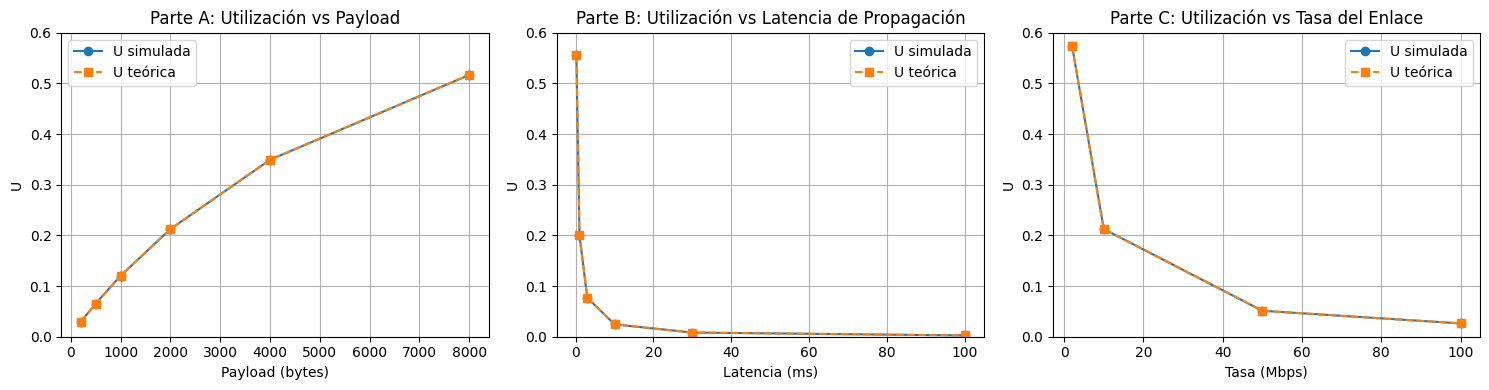

In [10]:
import heapq
import random
from dataclasses import dataclass, field
import pandas as pd
import matplotlib.pyplot as plt


# ======================== SIMULADOR ========================
class Simulator:
    def __init__(self):
        self.now = 0.0
        self.q = []  # heap de (time, idx, callable)
        self._counter = 0

    def at(self, t, fn):
        self._counter += 1
        heapq.heappush(self.q, (t, self._counter, fn))

    def call_later(self, dt, fn):
        self.at(self.now + dt, fn)

    def run(self, until=None):
        while self.q:
            t, _, fn = heapq.heappop(self.q)
            if until is not None and t > until:
                self.now = until
                break
            self.now = t
            fn()


# ======================== CANAL ========================
@dataclass
class ChannelDir:
    rate_bps: float
    prop_s: float
    p_drop: float = 0.0
    tx_ready_time: float = 0.0
    tx_busy_time: float = 0.0

    def send(self, sim: Simulator, bits: int, on_arrival):
        ser = bits / self.rate_bps
        start = max(sim.now, self.tx_ready_time)
        finish = start + ser
        self.tx_busy_time += ser
        self.tx_ready_time = finish
        arrival = finish + self.prop_s

        if random.random() < self.p_drop:
            # paquete perdido
            return dict(start=start, finish=finish, arrival=None, ser=ser)

        sim.at(arrival, on_arrival)
        return dict(start=start, finish=finish, arrival=arrival, ser=ser)


# ======================== RECEIVER ========================
class RX:
    def __init__(self, sim: Simulator, downlink: ChannelDir, ack_bits: int, proc_rx_s: float, log, log_limit=None):
        self.sim = sim
        self.down = downlink
        self.ack_bits = ack_bits
        self.proc_rx_s = proc_rx_s
        self.expected = 0
        self.delivered = 0
        self.log = log
        self.log_limit = log_limit

    def _log(self, msg):
        if self.log_limit is None or len(self.log) < self.log_limit:
            self.log.append(f"[t={self.sim.now*1e3:.3f} ms][RX] {msg}")

    def on_data_arrival(self, seq, size_bits, sender):
        self._log(f"llega DATA seq={seq}")

        def after_proc():
            if seq == self.expected:
                self.delivered += 1
                self.expected += 1
                self._log(f"entrego seq={seq}, envío ACK {seq}")
                meta = self.down.send(self.sim, sender.ack_bits,
                                      on_arrival=lambda: sender.on_ack_arrival(seq))
                self._log(
                    f"ACK{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] else None}s")
            else:
                last_ok = self.expected - 1
                self._log(f"fuera de orden (got={seq}, exp={self.expected}) -> re-ACK {last_ok}")
                self.down.send(self.sim, sender.ack_bits,
                               on_arrival=lambda: sender.on_ack_arrival(last_ok))

        self.sim.call_later(self.proc_rx_s, after_proc)


# ======================== TRANSMISOR ========================
class TX:
    def __init__(self, sim: Simulator, uplink: ChannelDir, frame_bits: int, ack_bits: int,
                 proc_tx_s: float, N_frames: int, log, log_limit=None, timeout_s=None):
        self.sim = sim
        self.up = uplink
        self.frame_bits = frame_bits
        self.ack_bits = ack_bits
        self.proc_tx_s = proc_tx_s
        self.N = N_frames
        self.next_seq = 0
        self.waiting_ack_for = None
        self.acks = 0
        self.sent_frames = 0
        self.log = log
        self.log_limit = log_limit
        self.done_cb = None
        self.receiver = None
        self.timeout_s = timeout_s
        self._timer_gen = 0

    def _log(self, msg):
        if self.log_limit is None or len(self.log) < self.log_limit:
            self.log.append(f"[t={self.sim.now*1e3:.3f} ms][TX] {msg}")

    def start(self, receiver: RX):
        self.receiver = receiver
        self._send_next()

    def _program_timeout(self, seq):
        if not self.timeout_s or self.timeout_s <= 0:
            return
        self._timer_gen += 1
        my_gen = self._timer_gen

        def on_timeout():
            if my_gen != self._timer_gen:
                return
            if self.waiting_ack_for == seq:
                self._log(f"TIMEOUT seq={seq} -> RETRANS")
                self._retransmit(seq)

        self.sim.call_later(self.timeout_s, on_timeout)

    def _send_next(self):
        if self.next_seq >= self.N:
            if self.done_cb:
                self.done_cb()
            return
        seq = self.next_seq
        self.waiting_ack_for = seq

        def after_proc():
            self._log(f"envío DATA seq={seq}")
            meta = self.up.send(self.sim, self.frame_bits,
                                on_arrival=lambda: self.receiver.on_data_arrival(seq, self.frame_bits, sender=self))
            self.sent_frames += 1
            self._log(
                f"DATA{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] else None}s")
            self._program_timeout(seq)

        self.sim.call_later(self.proc_tx_s, after_proc)

    def _retransmit(self, seq):
        def again():
            meta = self.up.send(self.sim, self.frame_bits,
                                on_arrival=lambda: self.receiver.on_data_arrival(seq, self.frame_bits, sender=self))
            self.sent_frames += 1
            self._log(
                f"RETX{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] else None}s")
            self._program_timeout(seq)

        self.sim.call_later(self.proc_tx_s, again)

    def on_ack_arrival(self, ackno):
        self._log(f"llega ACK {ackno}")
        if ackno == self.waiting_ack_for:
            self.acks += 1
            self.next_seq += 1
            self.waiting_ack_for = None
            self._timer_gen += 1
            self._send_next()


# ======================== FUNCIONES ========================
def run_simulation(link_rate_bps, payload_bytes, header_bytes, ack_bytes,
                   prop_delay_one_way_s, proc_tx_s, proc_rx_s,
                   N_frames, p_drop=0.0, timeout_s=None, log_limit=10):

    frame_bits = 8 * (payload_bytes + header_bytes)
    ack_bits = 8 * ack_bytes

    if timeout_s is None:
        Ttx_data = frame_bits / link_rate_bps
        Ttx_ack = ack_bits / link_rate_bps
        timeout_s = (2 * prop_delay_one_way_s) + Ttx_data + Ttx_ack + proc_tx_s + proc_rx_s + 0.002

    sim = Simulator()
    uplink = ChannelDir(rate_bps=link_rate_bps, prop_s=prop_delay_one_way_s, p_drop=p_drop)
    downlink = ChannelDir(rate_bps=link_rate_bps, prop_s=prop_delay_one_way_s, p_drop=p_drop)

    log = []
    rx = RX(sim, downlink, ack_bits, proc_rx_s, log, log_limit)
    tx = TX(sim, uplink, frame_bits, ack_bits, proc_tx_s, N_frames, log, log_limit, timeout_s)

    done = {"finished": False, "t_end": None}

    def on_done():
        done["finished"] = True
        done["t_end"] = sim.now

    tx.done_cb = on_done

    tx.start(receiver=rx)
    sim.run()

    t_total = done["t_end"] if done["t_end"] is not None else sim.now
    bits_total = frame_bits * N_frames
    utilization = (bits_total / t_total) / link_rate_bps if t_total > 0 else 0.0

    summary = {
        "frame_bits": frame_bits,
        "ack_bits": ack_bits,
        "frames_enviados": tx.sent_frames,
        "acks_recibidos": tx.acks,
        "tiempo_total_ms": t_total * 1e3,
        "ocupacion_uplink_ms": uplink.tx_busy_time * 1e3,
        "U": utilization,
        "p_drop": p_drop,
        "timeout_s": timeout_s,
    }
    return summary, log



def calcular_U_teorica(link_rate_bps, payload_bytes, header_bytes, ack_bytes,
                       prop_delay_one_way_s, p_error=0.0, proc_tx_s=0.0, proc_rx_s=0.0):
    frame_bits = 8 * (payload_bytes + header_bytes)
    ack_bits = 8 * ack_bytes

    Ttx_data = frame_bits / link_rate_bps
    Ttx_ack = ack_bits / link_rate_bps
    T_cycle = Ttx_data + Ttx_ack + (2 * prop_delay_one_way_s) + proc_tx_s + proc_rx_s

    if T_cycle == 0:
        return 0.0

    # Tiempo "útil" = Ttx_data. Por tanto U = (Ttx_data * (1 - p_error)) / T_cycle
    U = (Ttx_data * (1.0 - p_error)) / T_cycle

    # Aseguro que esté en [0,1]
    if U < 0:
        U = 0.0
    if U > 1:
        U = 1.0
    return U


# ======================== MAIN ========================
def main():
    # Variables base
    BASE_LINK_RATE_BPS = 10_000_000  # 10 Mbps
    BASE_PAYLOAD_BYTES = 600
    BASE_HEADER_BYTES = 25
    BASE_ACK_BYTES = 0
    BASE_PROP_DELAY_S = 0.003
    BASE_PROC_TX_S = 0.0
    BASE_PROC_RX_S = 0.0
    N_FRAMES = 1000
    P_DROP = 0.0

    random.seed(42)

    # --- Parte A: Variando Payload ---
    print("--- Parte A: Variando Payload ---")
    results_A = []
    payload_list_bytes = [200, 500, 1000, 2000, 4000, 8000]

    for payload in payload_list_bytes:
        summary, _ = run_simulation(BASE_LINK_RATE_BPS, payload, BASE_HEADER_BYTES,
                                    BASE_ACK_BYTES, BASE_PROP_DELAY_S,
                                    BASE_PROC_TX_S, BASE_PROC_RX_S,
                                    N_FRAMES, P_DROP)

        u_teorica = calcular_U_teorica(BASE_LINK_RATE_BPS, payload, BASE_HEADER_BYTES,
                                       BASE_ACK_BYTES, BASE_PROP_DELAY_S, P_DROP,
                                       BASE_PROC_TX_S, BASE_PROC_RX_S)

        results_A.append({
            "payload_bytes": payload,
            "U_simulada": summary["U"],
            "U_teorica": u_teorica,
            "tiempo_total_ms": summary["tiempo_total_ms"]
        })

    df_A = pd.DataFrame(results_A)
    print(df_A.to_string(index=False))

    # --- Parte B: Variar Propagación ---
    print("\n--- Parte B: Variando Propagación (Latencia) ---")
    results_B = []
    prop_delay_list_s = [0.0002, 0.001, 0.003, 0.01, 0.03, 0.1]

    for delay in prop_delay_list_s:
        summary, _ = run_simulation(BASE_LINK_RATE_BPS, BASE_PAYLOAD_BYTES, BASE_HEADER_BYTES,
                                    BASE_ACK_BYTES, delay,
                                    BASE_PROC_TX_S, BASE_PROC_RX_S,
                                    N_FRAMES, P_DROP)

        u_teorica = calcular_U_teorica(BASE_LINK_RATE_BPS, BASE_PAYLOAD_BYTES, BASE_HEADER_BYTES,
                                       BASE_ACK_BYTES, delay, P_DROP,
                                       BASE_PROC_TX_S, BASE_PROC_RX_S)

        results_B.append({
            "prop_delay_ms": delay * 1000,
            "U_simulada": summary["U"],
            "U_teorica": u_teorica
        })

    df_B = pd.DataFrame(results_B)
    print(df_B.to_string(index=False))

    # --- Parte C: Variando Tasa ---
    print("\n--- Parte C: Variando Tasa (R) ---")
    results_C = []
    rate_list_bps = [2_000_000, 10_000_000, 50_000_000, 100_000_000]

    for rate in rate_list_bps:
        summary, _ = run_simulation(rate, 2000, BASE_HEADER_BYTES,
                                    BASE_ACK_BYTES, 0.003,
                                    BASE_PROC_TX_S, BASE_PROC_RX_S,
                                    N_FRAMES, P_DROP)

        u_teorica = calcular_U_teorica(rate, 2000, BASE_HEADER_BYTES,
                                       BASE_ACK_BYTES, 0.003, P_DROP,
                                       BASE_PROC_TX_S, BASE_PROC_RX_S)

        results_C.append({
            "link_rate_mbps": rate / 1_000_000,
            "U_simulada": summary["U"],
            "U_teorica": u_teorica
        })

    df_C = pd.DataFrame(results_C)
    print(df_C.to_string(index=False))

    # ==================== GRÁFICOS MATPLOTLIB ====================
    plt.figure(figsize=(15, 4))

    # --- Gráfico A ---
    plt.subplot(1, 3, 1)
    plt.plot(df_A["payload_bytes"], df_A["U_simulada"], 'o-', label="U simulada")
    plt.plot(df_A["payload_bytes"], df_A["U_teorica"], 's--', label="U teórica")
    plt.title("Parte A: Utilización vs Payload")
    plt.xlabel("Payload (bytes)")
    plt.ylabel("U")
    plt.ylim(0, .6)
    plt.legend()
    plt.grid(True)

    # --- Gráfico B ---
    plt.subplot(1, 3, 2)
    plt.plot(df_B["prop_delay_ms"], df_B["U_simulada"], 'o-', label="U simulada")
    plt.plot(df_B["prop_delay_ms"], df_B["U_teorica"], 's--', label="U teórica")
    plt.title("Parte B: Utilización vs Latencia de Propagación")
    plt.xlabel("Latencia (ms)")
    plt.ylabel("U")
    plt.ylim(0, .6)
    plt.legend()
    plt.grid(True)

    # --- Gráfico C ---
    plt.subplot(1, 3, 3)
    plt.plot(df_C["link_rate_mbps"], df_C["U_simulada"], 'o-', label="U simulada")
    plt.plot(df_C["link_rate_mbps"], df_C["U_teorica"], 's--', label="U teórica")
    plt.title("Parte C: Utilización vs Tasa del Enlace")
    plt.xlabel("Tasa (Mbps)")
    plt.ylabel("U")
    plt.ylim(0, .6)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


**Discuta aquí los resultados comparandolos con los resultados teóricos**

En Stop-and-Wait sin pérdidas, la utilización muestra claros compromisos entre los parámetros:

1. TAMAÑO DE PAYLOAD: Utilización mejora con payloads más grandes, ya que el tiempo de transmisión útil aumenta mientras los tiempos fijos (propagación, ACK) se mantienen.

2. DELAY DE PROPAGACIÓN: Utilización disminuye drásticamente con mayores delays, pues el canal permanece inactivo esperando ACKs. Para delays altos, Stop-and-Wait es muy ineficiente.

3. TASA DEL ENLACE: Utilización disminuye con tasas más altas, porque la transmisión es más rápida pero los tiempos de propagación fijos dominan el ciclo.

Stop-and-Wait es eficiente solo cuando: RTT es pequeño comparado con el tiempo de transmisión, o cuando el tamaño de trama es muy grande.


## Ejercicio 2: Tamaño de ACK
Repita el ejercicio anterior para un para probabilidad de perdidad de tramas de 0.1


--- Parte A: Variando Payload ---
 payload_bytes  U_simulada  U_teorica  tiempo_total_ms
           200    0.022488   0.026214          8004.14
           500    0.050617   0.058879          8297.66
          1000    0.092302   0.108211          8883.88
          2000    0.163797   0.191339          9890.32
          4000    0.274171   0.314317         11744.50
          8000    0.410600   0.465217         15635.66

--- Parte B: Variando Propagación (Latencia) ---
 prop_delay_ms  U_simulada  U_teorica
           0.2    0.312715   0.500000
           1.0    0.139665   0.180000
           3.0    0.058723   0.069231
          10.0    0.018943   0.021951
          30.0    0.006689   0.007438
         100.0    0.002035   0.002244

--- Parte C: Variando Tasa (R) ---
 link_rate_mbps  U_simulada  U_teorica
            2.0    0.459551   0.517021
           10.0    0.163478   0.191339
           50.0    0.039130   0.046110
          100.0    0.021138   0.023661


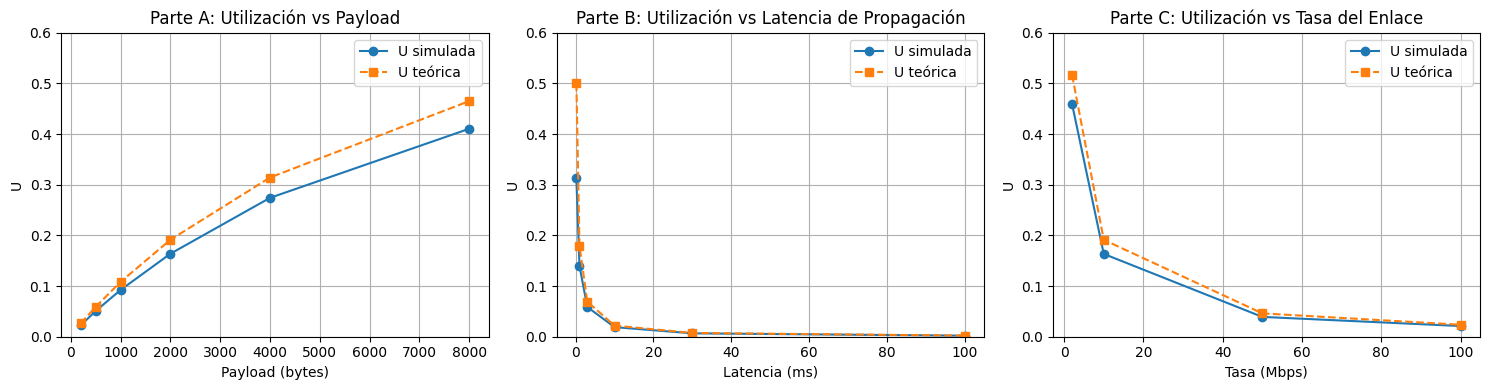

In [11]:
import heapq
import random
from dataclasses import dataclass, field
import pandas as pd
import matplotlib.pyplot as plt


# ======================== SIMULADOR ========================
class Simulator:
    def __init__(self):
        self.now = 0.0
        self.q = []  # heap de (time, idx, callable)
        self._counter = 0

    def at(self, t, fn):
        self._counter += 1
        heapq.heappush(self.q, (t, self._counter, fn))

    def call_later(self, dt, fn):
        self.at(self.now + dt, fn)

    def run(self, until=None):
        while self.q:
            t, _, fn = heapq.heappop(self.q)
            if until is not None and t > until:
                self.now = until
                break
            self.now = t
            fn()


# ======================== CANAL ========================
@dataclass
class ChannelDir:
    rate_bps: float
    prop_s: float
    p_drop: float = 0.0
    tx_ready_time: float = 0.0
    tx_busy_time: float = 0.0

    def send(self, sim: Simulator, bits: int, on_arrival):
        ser = bits / self.rate_bps
        start = max(sim.now, self.tx_ready_time)
        finish = start + ser
        self.tx_busy_time += ser
        self.tx_ready_time = finish
        arrival = finish + self.prop_s

        if random.random() < self.p_drop:
            # paquete perdido
            return dict(start=start, finish=finish, arrival=None, ser=ser)

        sim.at(arrival, on_arrival)
        return dict(start=start, finish=finish, arrival=arrival, ser=ser)


# ======================== RECEIVER ========================
class RX:
    def __init__(self, sim: Simulator, downlink: ChannelDir, ack_bits: int, proc_rx_s: float, log, log_limit=None):
        self.sim = sim
        self.down = downlink
        self.ack_bits = ack_bits
        self.proc_rx_s = proc_rx_s
        self.expected = 0
        self.delivered = 0
        self.log = log
        self.log_limit = log_limit

    def _log(self, msg):
        if self.log_limit is None or len(self.log) < self.log_limit:
            self.log.append(f"[t={self.sim.now*1e3:.3f} ms][RX] {msg}")

    def on_data_arrival(self, seq, size_bits, sender):
        self._log(f"llega DATA seq={seq}")

        def after_proc():
            if seq == self.expected:
                self.delivered += 1
                self.expected += 1
                self._log(f"entrego seq={seq}, envío ACK {seq}")
                meta = self.down.send(self.sim, sender.ack_bits,
                                      on_arrival=lambda: sender.on_ack_arrival(seq))
                self._log(
                    f"ACK{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] else None}s")
            else:
                last_ok = self.expected - 1
                self._log(f"fuera de orden (got={seq}, exp={self.expected}) -> re-ACK {last_ok}")
                self.down.send(self.sim, sender.ack_bits,
                               on_arrival=lambda: sender.on_ack_arrival(last_ok))

        self.sim.call_later(self.proc_rx_s, after_proc)


# ======================== TRANSMISOR ========================
class TX:
    def __init__(self, sim: Simulator, uplink: ChannelDir, frame_bits: int, ack_bits: int,
                 proc_tx_s: float, N_frames: int, log, log_limit=None, timeout_s=None):
        self.sim = sim
        self.up = uplink
        self.frame_bits = frame_bits
        self.ack_bits = ack_bits
        self.proc_tx_s = proc_tx_s
        self.N = N_frames
        self.next_seq = 0
        self.waiting_ack_for = None
        self.acks = 0
        self.sent_frames = 0
        self.log = log
        self.log_limit = log_limit
        self.done_cb = None
        self.receiver = None
        self.timeout_s = timeout_s
        self._timer_gen = 0

    def _log(self, msg):
        if self.log_limit is None or len(self.log) < self.log_limit:
            self.log.append(f"[t={self.sim.now*1e3:.3f} ms][TX] {msg}")

    def start(self, receiver: RX):
        self.receiver = receiver
        self._send_next()

    def _program_timeout(self, seq):
        if not self.timeout_s or self.timeout_s <= 0:
            return
        self._timer_gen += 1
        my_gen = self._timer_gen

        def on_timeout():
            if my_gen != self._timer_gen:
                return
            if self.waiting_ack_for == seq:
                self._log(f"TIMEOUT seq={seq} -> RETRANS")
                self._retransmit(seq)

        self.sim.call_later(self.timeout_s, on_timeout)

    def _send_next(self):
        if self.next_seq >= self.N:
            if self.done_cb:
                self.done_cb()
            return
        seq = self.next_seq
        self.waiting_ack_for = seq

        def after_proc():
            self._log(f"envío DATA seq={seq}")
            meta = self.up.send(self.sim, self.frame_bits,
                                on_arrival=lambda: self.receiver.on_data_arrival(seq, self.frame_bits, sender=self))
            self.sent_frames += 1
            self._log(
                f"DATA{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] else None}s")
            self._program_timeout(seq)

        self.sim.call_later(self.proc_tx_s, after_proc)

    def _retransmit(self, seq):
        def again():
            meta = self.up.send(self.sim, self.frame_bits,
                                on_arrival=lambda: self.receiver.on_data_arrival(seq, self.frame_bits, sender=self))
            self.sent_frames += 1
            self._log(
                f"RETX{seq} tx {meta['ser']*1e3:.3f}ms; llega en {(meta['arrival']-self.sim.now) if meta['arrival'] else None}s")
            self._program_timeout(seq)

        self.sim.call_later(self.proc_tx_s, again)

    def on_ack_arrival(self, ackno):
        self._log(f"llega ACK {ackno}")
        if ackno == self.waiting_ack_for:
            self.acks += 1
            self.next_seq += 1
            self.waiting_ack_for = None
            self._timer_gen += 1
            self._send_next()


# ======================== FUNCIONES ========================
def run_simulation(link_rate_bps, payload_bytes, header_bytes, ack_bytes,
                   prop_delay_one_way_s, proc_tx_s, proc_rx_s,
                   N_frames, p_drop=0.0, timeout_s=None, log_limit=10):

    frame_bits = 8 * (payload_bytes + header_bytes)
    ack_bits = 8 * ack_bytes

    if timeout_s is None:
        Ttx_data = frame_bits / link_rate_bps
        Ttx_ack = ack_bits / link_rate_bps
        timeout_s = (2 * prop_delay_one_way_s) + Ttx_data + Ttx_ack + proc_tx_s + proc_rx_s + 0.002

    sim = Simulator()
    uplink = ChannelDir(rate_bps=link_rate_bps, prop_s=prop_delay_one_way_s, p_drop=p_drop)
    downlink = ChannelDir(rate_bps=link_rate_bps, prop_s=prop_delay_one_way_s, p_drop=p_drop)

    log = []
    rx = RX(sim, downlink, ack_bits, proc_rx_s, log, log_limit)
    tx = TX(sim, uplink, frame_bits, ack_bits, proc_tx_s, N_frames, log, log_limit, timeout_s)

    done = {"finished": False, "t_end": None}

    def on_done():
        done["finished"] = True
        done["t_end"] = sim.now

    tx.done_cb = on_done

    tx.start(receiver=rx)
    sim.run()

    t_total = done["t_end"] if done["t_end"] is not None else sim.now
    bits_total = frame_bits * N_frames
    utilization = (bits_total / t_total) / link_rate_bps if t_total > 0 else 0.0

    summary = {
        "frame_bits": frame_bits,
        "ack_bits": ack_bits,
        "frames_enviados": tx.sent_frames,
        "acks_recibidos": tx.acks,
        "tiempo_total_ms": t_total * 1e3,
        "ocupacion_uplink_ms": uplink.tx_busy_time * 1e3,
        "U": utilization,
        "p_drop": p_drop,
        "timeout_s": timeout_s,
    }
    return summary, log



def calcular_U_teorica(link_rate_bps, payload_bytes, header_bytes, ack_bytes,
                       prop_delay_one_way_s, p_error=0.0, proc_tx_s=0.0, proc_rx_s=0.0):
    frame_bits = 8 * (payload_bytes + header_bytes)
    ack_bits = 8 * ack_bytes

    Ttx_data = frame_bits / link_rate_bps
    Ttx_ack = ack_bits / link_rate_bps
    T_cycle = Ttx_data + Ttx_ack + (2 * prop_delay_one_way_s) + proc_tx_s + proc_rx_s

    if T_cycle == 0:
        return 0.0

    # Tiempo "útil" = Ttx_data. Por tanto U = (Ttx_data * (1 - p_error)) / T_cycle
    U = (Ttx_data * (1.0 - p_error)) / T_cycle

    # Aseguro que esté en [0,1]
    if U < 0:
        U = 0.0
    if U > 1:
        U = 1.0
    return U


# ======================== MAIN ========================
def main():
    # Variables base
    BASE_LINK_RATE_BPS = 10_000_000  # 10 Mbps
    BASE_PAYLOAD_BYTES = 600
    BASE_HEADER_BYTES = 25
    BASE_ACK_BYTES = 0
    BASE_PROP_DELAY_S = 0.003
    BASE_PROC_TX_S = 0.0
    BASE_PROC_RX_S = 0.0
    N_FRAMES = 1000
    P_DROP = 0.10

    random.seed(42)

    # --- Parte A: Variando Payload ---
    print("--- Parte A: Variando Payload ---")
    results_A = []
    payload_list_bytes = [200, 500, 1000, 2000, 4000, 8000]

    for payload in payload_list_bytes:
        summary, _ = run_simulation(BASE_LINK_RATE_BPS, payload, BASE_HEADER_BYTES,
                                    BASE_ACK_BYTES, BASE_PROP_DELAY_S,
                                    BASE_PROC_TX_S, BASE_PROC_RX_S,
                                    N_FRAMES, P_DROP)

        u_teorica = calcular_U_teorica(BASE_LINK_RATE_BPS, payload, BASE_HEADER_BYTES,
                                       BASE_ACK_BYTES, BASE_PROP_DELAY_S, P_DROP,
                                       BASE_PROC_TX_S, BASE_PROC_RX_S)

        results_A.append({
            "payload_bytes": payload,
            "U_simulada": summary["U"],
            "U_teorica": u_teorica,
            "tiempo_total_ms": summary["tiempo_total_ms"]
        })

    df_A = pd.DataFrame(results_A)
    print(df_A.to_string(index=False))

    # --- Parte B: Variar Propagación ---
    print("\n--- Parte B: Variando Propagación (Latencia) ---")
    results_B = []
    prop_delay_list_s = [0.0002, 0.001, 0.003, 0.01, 0.03, 0.1]

    for delay in prop_delay_list_s:
        summary, _ = run_simulation(BASE_LINK_RATE_BPS, BASE_PAYLOAD_BYTES, BASE_HEADER_BYTES,
                                    BASE_ACK_BYTES, delay,
                                    BASE_PROC_TX_S, BASE_PROC_RX_S,
                                    N_FRAMES, P_DROP)

        u_teorica = calcular_U_teorica(BASE_LINK_RATE_BPS, BASE_PAYLOAD_BYTES, BASE_HEADER_BYTES,
                                       BASE_ACK_BYTES, delay, P_DROP,
                                       BASE_PROC_TX_S, BASE_PROC_RX_S)

        results_B.append({
            "prop_delay_ms": delay * 1000,
            "U_simulada": summary["U"],
            "U_teorica": u_teorica
        })

    df_B = pd.DataFrame(results_B)
    print(df_B.to_string(index=False))

    # --- Parte C: Variando Tasa ---
    print("\n--- Parte C: Variando Tasa (R) ---")
    results_C = []
    rate_list_bps = [2_000_000, 10_000_000, 50_000_000, 100_000_000]

    for rate in rate_list_bps:
        summary, _ = run_simulation(rate, 2000, BASE_HEADER_BYTES,
                                    BASE_ACK_BYTES, 0.003,
                                    BASE_PROC_TX_S, BASE_PROC_RX_S,
                                    N_FRAMES, P_DROP)

        u_teorica = calcular_U_teorica(rate, 2000, BASE_HEADER_BYTES,
                                       BASE_ACK_BYTES, 0.003, P_DROP,
                                       BASE_PROC_TX_S, BASE_PROC_RX_S)

        results_C.append({
            "link_rate_mbps": rate / 1_000_000,
            "U_simulada": summary["U"],
            "U_teorica": u_teorica
        })

    df_C = pd.DataFrame(results_C)
    print(df_C.to_string(index=False))

    # ==================== GRÁFICOS MATPLOTLIB ====================
    plt.figure(figsize=(15, 4))

    # --- Gráfico A ---
    plt.subplot(1, 3, 1)
    plt.plot(df_A["payload_bytes"], df_A["U_simulada"], 'o-', label="U simulada")
    plt.plot(df_A["payload_bytes"], df_A["U_teorica"], 's--', label="U teórica")
    plt.title("Parte A: Utilización vs Payload")
    plt.xlabel("Payload (bytes)")
    plt.ylabel("U")
    plt.ylim(0, .6)
    plt.legend()
    plt.grid(True)

    # --- Gráfico B ---
    plt.subplot(1, 3, 2)
    plt.plot(df_B["prop_delay_ms"], df_B["U_simulada"], 'o-', label="U simulada")
    plt.plot(df_B["prop_delay_ms"], df_B["U_teorica"], 's--', label="U teórica")
    plt.title("Parte B: Utilización vs Latencia de Propagación")
    plt.xlabel("Latencia (ms)")
    plt.ylabel("U")
    plt.ylim(0, .6)
    plt.legend()
    plt.grid(True)

    # --- Gráfico C ---
    plt.subplot(1, 3, 3)
    plt.plot(df_C["link_rate_mbps"], df_C["U_simulada"], 'o-', label="U simulada")
    plt.plot(df_C["link_rate_mbps"], df_C["U_teorica"], 's--', label="U teórica")
    plt.title("Parte C: Utilización vs Tasa del Enlace")
    plt.xlabel("Tasa (Mbps)")
    plt.ylabel("U")
    plt.ylim(0, .6)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


**Discuta aquí los resultados comparandolos con los resultados teóricos**

En todos los casos de la simulacion con una tasa de perdidas del 01. , la tasa de utilizacion de la simulación está por debajo (valores menores) que la tasa de utilizacion teorica.

Las mayores diferencias se ven a medida que aumenta el payload, ya que retrasmitir un frame se hace cada vez mas "costoso" restransmitirlo a medida que el tamaño del frame aumenta

Si bien las conclusiones anteriores sobre la latencia, el payload y la tasa siguen siendo ciertas, la introducción de pérdidas agrava exponencialmente la ineficiencia de Stop-and-Wait.

Un protocolo que ya era "limitado por latencia" (como vimos en las partes B y C del Ejercicio 1) se vuelve aun mas limitado cuando, además, debe gastar la mayoría de su tiempo recuperándose de timeouts en lugar de enviando datos nuevos.